**# CELL 1: Setup & Imports (Training Notebook) - WITH MobilePlantViT**

This cell imports all required libraries and sets up the MobilePlantViT model.

**Requirements:**
- `mobileplantvit-source-code` dataset must be added to this notebook
- `plantvillage-color-preprocessed` dataset must be added to this notebook

**Imported Components:**
- Standard libraries: os, sys, json, datetime, collections, time
- Data science: numpy, matplotlib, PIL
- Deep learning: torch, torchvision
- MobilePlantViT: model classes, config, factory functions, building blocks

In [ ]:
# ============================================================================
# CELL 1: Setup & Imports (Training Notebook) - WITH MobilePlantViT
# ============================================================================
"""
This cell sets up all necessary imports including MobilePlantViT.

Requirements:
- Add 'mobileplantvit-source-code' dataset to this notebook
- Add 'plantvillage-color-preprocessed' dataset to this notebook
"""

import os
import sys
import json
from datetime import datetime
from collections import OrderedDict, Counter
import time

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler

# ============================================================================
# MOBILEPLANT-VIT SOURCE SETUP
# ============================================================================
# Configuration - Update this if your dataset has a different name
MOBILEPLANT_VIT_SOURCE_DATASET = 'mobileplantvit-source-code'

# Determine environment (Kaggle or Local)
IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    # Kaggle environment
    source_path = f'/kaggle/input/{MOBILEPLANT_VIT_SOURCE_DATASET}'
    
    if os.path.exists(source_path):
        # Add to Python path
        if source_path not in sys.path:
            sys.path.insert(0, source_path)
        print(f"✅ MobilePlantViT source path added: {source_path}")
        
        # Verify structure exists
        expected_files = [
            'src/__init__.py',
            'src/models/__init__.py',
            'src/models/mobile_plant_vit.py',
            'src/blocks/__init__.py',
        ]
        
        missing = [f for f in expected_files if not os.path.exists(os.path.join(source_path, f))]
        if missing:
            print(f"⚠️  Warning: Missing files in source dataset: {missing}")
    else:
        print(f"❌ ERROR: MobilePlantViT source not found at {source_path}")
        print(f"\n   To fix this:")
        print(f"   1. Click 'Add Data' button (right panel)")
        print(f"   2. Search for '{MOBILEPLANT_VIT_SOURCE_DATASET}'")
        print(f"   3. Click 'Add' to add the dataset")
        print(f"   4. Re-run this cell")
        print(f"\n   Available datasets in /kaggle/input/:")
        if os.path.exists('/kaggle/input'):
            for item in os.listdir('/kaggle/input'):
                print(f"   - {item}")
        raise FileNotFoundError(f"Please add '{MOBILEPLANT_VIT_SOURCE_DATASET}' dataset to this notebook")
else:
    # Local environment - assume running from project root
    local_paths = [
        '.',  # Current directory
        os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else '.',
    ]
    
    source_path = None
    for path in local_paths:
        if os.path.exists(os.path.join(path, 'src', '__init__.py')):
            source_path = path
            break
    
    if source_path:
        if source_path not in sys.path:
            sys.path.insert(0, source_path)
        print(f"✅ Local source path added: {source_path}")
    else:
        print("⚠️  Running in local mode but src/ not found in expected locations")

# ============================================================================
# IMPORT MOBILEPLANT-VIT COMPONENTS
# ============================================================================
try:
    # Import main model and config
    from src.models import (
        MobilePlantViT,
        MobilePlantViTConfig,
        mobileplant_vit_tiny,
        mobileplant_vit_small,
        mobileplant_vit_base,
        mobileplant_vit_large,
    )
    
    # Import blocks (optional - useful for debugging/analysis)
    from src.blocks import (
        GhostConv,
        FusedInvertedResidualBlock,
        CoordAtt,
        PatchEmbedding,
        PositionalEncoding,
        LinearDifferentialAttention,
        ResidualLayerNormBlock,
        BottleneckFFN,
        GlobalAveragePooling,
        ClassifierHead,
    )
    
    MOBILEPLANT_VIT_AVAILABLE = True
    print("✅ MobilePlantViT components imported successfully!")
    
    # Quick verification - create and delete a test model
    _test_model = MobilePlantViT(num_classes=10)
    _test_params = _test_model.count_parameters()
    print(f"   Verification: Model instantiation OK ({_test_params:,} params)")
    del _test_model
    
except ImportError as e:
    MOBILEPLANT_VIT_AVAILABLE = False
    print(f"❌ Failed to import MobilePlantViT: {e}")
    print(f"\n   Troubleshooting:")
    print(f"   1. Verify the source dataset is added to this notebook")
    print(f"   2. Check that all __init__.py files are present")
    print(f"   3. Verify sys.path includes the source dataset path")
    print(f"\n   Current sys.path:")
    for p in sys.path[:5]:
        print(f"   - {p}")
    print(f"\n   Falling back to MobileNetV2 only mode.")

# ============================================================================
# SET RANDOM SEEDS FOR REPRODUCIBILITY
# ============================================================================
RANDOM_SEED = 42
import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("  SETUP COMPLETE")
print("=" * 70)
print(f"  PyTorch:              {torch.__version__}")
print(f"  CUDA Available:       {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU:                  {torch.cuda.get_device_name(0)}")
print(f"  Random Seed:          {RANDOM_SEED}")
print(f"  MobilePlantViT:       {'✅ Available' if MOBILEPLANT_VIT_AVAILABLE else '❌ Not Available'}")

if MOBILEPLANT_VIT_AVAILABLE:
    print(f"\n  Available MobilePlantViT variants:")
    print(f"    • mobileplant_vit_tiny()   ~220K params  (edge devices)")
    print(f"    • mobileplant_vit_small()  ~490K params  (mobile)")
    print(f"    • mobileplant_vit_base()   ~867K params  (default)")
    print(f"    • mobileplant_vit_large()  ~1.9M params  (high capacity)")

print("=" * 70)

**# CELL 2: Load Preprocessed Dataset from Kaggle**

In [2]:
# CELL 2: Load Preprocessed Dataset from Kaggle

print("\n" + "=" * 80)
print("  LOADING PREPROCESSED DATASET")
print("=" * 80)

# ============================================================================
# CONFIGURATION: Update this path based on your Kaggle dataset name
# ============================================================================
PREPROCESSED_DATASET_NAME = 'plantvillage-color-preprocessed'  # Change if different
# ============================================================================

# Construct paths
kaggle_input_path = f'/kaggle/input/{PREPROCESSED_DATASET_NAME}'
working_base = '/kaggle/working/MobilePlantViT'

# Create working directory
os.makedirs(working_base, exist_ok=True)

# Verify dataset exists
if not os.path.exists(kaggle_input_path):
    print(f"❌ ERROR: Dataset not found at {kaggle_input_path}")
    print(f"\n   Available datasets in /kaggle/input/:")
    for item in os.listdir('/kaggle/input'):
        print(f"   - {item}")
    raise FileNotFoundError(f"Please add '{PREPROCESSED_DATASET_NAME}' dataset to this notebook")

print(f"✅ Dataset found at: {kaggle_input_path}")

# Load metadata
metadata_path = os.path.join(kaggle_input_path, 'dataset_metadata.json')

if os.path.exists(metadata_path):
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    print(f"✅ Metadata loaded")
else:
    raise FileNotFoundError(f"Metadata file not found at {metadata_path}")

# Extract configuration from metadata
NUM_CLASSES = metadata['num_classes']
CLASS_NAMES = metadata['class_names']
SPLIT_RATIO = metadata['split_ratio']
split_stats = metadata['split_stats']
IMAGENET_MEAN = metadata['imagenet_mean']
IMAGENET_STD = metadata['imagenet_std']
imbalance_ratio = metadata['imbalance_ratio_original']
BALANCING_STRATEGY = metadata['balancing_strategy']

# Set directory paths (pointing to Kaggle input - READ ONLY)
train_dir = os.path.join(kaggle_input_path, 'train')
val_dir = os.path.join(kaggle_input_path, 'val')
test_dir = os.path.join(kaggle_input_path, 'test')

# DataLoader settings
BATCH_SIZE = 64  # Can be modified for experiments
NUM_WORKERS = 4
PIN_MEMORY = True

# Display loaded configuration
print(f"\n📊 Dataset Configuration (from metadata):")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Train Images: {split_stats['train_images']:,}")
print(f"   Val Images: {split_stats['val_images']:,}")
print(f"   Test Images: {split_stats['test_images']:,}")
print(f"   Total Images: {split_stats['total_images']:,}")
print(f"   Imbalance Ratio: {imbalance_ratio:.2f}x")
print(f"   Balancing Strategy: {BALANCING_STRATEGY}")
print(f"   Created: {metadata['creation_date']}")

# Verify directories exist
for dir_path, dir_name in [(train_dir, 'Train'), (val_dir, 'Val'), (test_dir, 'Test')]:
    if os.path.exists(dir_path):
        num_classes = len([d for d in os.listdir(dir_path) if os.path.isdir(os.path.join(dir_path, d))])
        print(f"   ✅ {dir_name} directory: {num_classes} classes")
    else:
        print(f"   ❌ {dir_name} directory NOT FOUND!")

print("\n✅ Preprocessed dataset loaded successfully!")


  LOADING PREPROCESSED DATASET
✅ Dataset found at: /kaggle/input/plantvillage-color-preprocessed
✅ Metadata loaded

📊 Dataset Configuration (from metadata):
   Classes: 38
   Train Images: 34,539
   Val Images: 7,388
   Test Images: 7,443
   Total Images: 49,370
   Imbalance Ratio: 35.30x
   Balancing Strategy: weighted_sampling
   Created: 2025-11-28 03:50:44
   ✅ Train directory: 38 classes
   ✅ Val directory: 38 classes
   ✅ Test directory: 38 classes

✅ Preprocessed dataset loaded successfully!


**# CELL 3: Helper Functions**

In [3]:
# CELL 3: Helper Functions

def print_section(title):
    """Print formatted section header."""
    print("\n" + "=" * 80)
    print(f"  {title}")
    print("=" * 80)


def count_images_in_dir(directory):
    """Count total images and classes in a directory."""
    total_images = 0
    class_distribution = OrderedDict()
    
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            class_distribution[class_name] = len(images)
            total_images += len(images)
    
    return total_images, class_distribution


def calculate_class_weights(class_distribution):
    """Calculate class weights for weighted loss using inverse frequency."""
    total_samples = sum(class_distribution.values())
    num_classes = len(class_distribution)
    
    class_weights = {}
    for class_name, count in class_distribution.items():
        weight = total_samples / (num_classes * count)
        class_weights[class_name] = weight
    
    return class_weights


def create_weighted_sampler(dataset, class_distribution):
    """Create WeightedRandomSampler for balanced batch sampling."""
    class_weights = calculate_class_weights(class_distribution)
    
    sample_weights = []
    for img_path, class_idx in dataset.samples:
        class_name = dataset.classes[class_idx]
        sample_weights.append(class_weights[class_name])
    
    sample_weights = torch.DoubleTensor(sample_weights)
    
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    
    return sampler


def denormalize(tensor):
    """Denormalize tensor for visualization."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, IMAGENET_MEAN, IMAGENET_STD):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)


print("✅ Helper functions defined")

✅ Helper functions defined


**# CELL 4: Define Transformations**

In [4]:
# CELL 4: Define Transformations

print_section("PREPROCESSING PIPELINE")

# Training transform (WITH augmentations)
transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), 
                           scale=(0.9, 1.1), shear=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, 
                          saturation=0.2, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Val/Test transform (NO augmentations)
transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print(f"✅ Transforms defined")
print(f"   Train:    {len(transform_train.transforms)} steps (WITH augmentations)")
print(f"   Val/Test: {len(transform_val_test.transforms)} steps (NO augmentations)")


  PREPROCESSING PIPELINE
✅ Transforms defined
   Train:    9 steps (WITH augmentations)
   Val/Test: 3 steps (NO augmentations)


**# CELL 5: Create Datasets**

In [5]:
# CELL 5: Create Datasets

print_section("DATASET CREATION")

train_dataset = datasets.ImageFolder(train_dir, transform=transform_train)
val_dataset = datasets.ImageFolder(val_dir, transform=transform_val_test)
test_dataset = datasets.ImageFolder(test_dir, transform=transform_val_test)

print(f"✅ Datasets created")
print(f"   Train: {len(train_dataset):,} images")
print(f"   Val:   {len(val_dataset):,} images")
print(f"   Test:  {len(test_dataset):,} images")
print(f"   Classes: {len(train_dataset.classes)}")

# Verify class order matches metadata
if train_dataset.classes == CLASS_NAMES:
    print(f"   ✅ Class order matches metadata")
else:
    print(f"   ⚠️  Class order differs from metadata - using dataset order")
    CLASS_NAMES = train_dataset.classes


  DATASET CREATION
✅ Datasets created
   Train: 34,539 images
   Val:   7,388 images
   Test:  7,443 images
   Classes: 38
   ✅ Class order matches metadata


**# CELL 6: Create DataLoaders**

In [6]:
# CELL 6: Create DataLoaders

print_section("DATALOADER CREATION")

# Safer worker count for Kaggle
NUM_WORKERS = min(4, os.cpu_count() or 2)

# Determine if we need weighted sampling
use_weighted_sampling = (BALANCING_STRATEGY == 'weighted_sampling' and 
                         imbalance_ratio > 2.0)

if use_weighted_sampling:
    print("🔄 Creating weighted sampler for balanced batches...")
    
    # Get train set class distribution
    train_class_dist = count_images_in_dir(train_dir)[1]
    
    # Create weighted sampler
    train_sampler = create_weighted_sampler(train_dataset, train_class_dist)
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        prefetch_factor=2,
        persistent_workers=True
    )
    
    print(f"✅ Weighted sampling enabled")
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        prefetch_factor=2,
        persistent_workers=True
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=2,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    prefetch_factor=2,
    persistent_workers=True
)

print(f"\n✅ DataLoaders created")
print(f"   Train: {len(train_loader)} batches (balanced={use_weighted_sampling})")
print(f"   Val:   {len(val_loader)} batches")
print(f"   Test:  {len(test_loader)} batches")


  DATALOADER CREATION
🔄 Creating weighted sampler for balanced batches...
✅ Weighted sampling enabled

✅ DataLoaders created
   Train: 540 batches (balanced=True)
   Val:   116 batches
   Test:  117 batches


**# CELL 7: Model Configuration**

This cell configures the model architecture and training hyperparameters.

**Model Selection:**
- `MODEL_TYPE`: Choose between `'mobileplant_vit'` or `'mobilenet_v2'` (baseline)
- `MODEL_VARIANT`: For MobilePlantViT, select `'tiny'`, `'small'`, `'base'`, `'large'`, or `'custom'`

**Training Configuration:**
- Optimizer settings (learning rate, weight decay)
- Scheduler settings
- Training epochs
- Gradient clipping

**Comparison Mode:**
- Set `COMPARISON_MODE = True` to train both models for comparison

In [ ]:
# ============================================================================
# CELL 7: Model Configuration
# ============================================================================
"""
Central configuration for model selection and training hyperparameters.
Modify these settings to experiment with different configurations.
"""

print_section("MODEL CONFIGURATION")

# ============================================================================
# MODEL SELECTION
# ============================================================================
# Choose the model type: 'mobileplant_vit' or 'mobilenet_v2'
MODEL_TYPE = 'mobileplant_vit'  # Options: 'mobileplant_vit', 'mobilenet_v2'

# For MobilePlantViT: select variant
# Options: 'tiny', 'small', 'base', 'large', 'custom'
MODEL_VARIANT = 'base'

# Comparison mode: train both models for side-by-side comparison
COMPARISON_MODE = False  # Set True to train both MobilePlantViT and MobileNetV2

# ============================================================================
# CUSTOM CONFIGURATION (only used if MODEL_VARIANT = 'custom')
# ============================================================================
CUSTOM_CONFIG = {
    # CNN Stage
    'ghost_out_channels': 64,           # GhostConv output channels (default: 64)
    'fused_ir_out_channels': 128,       # Fused-IR output channels (default: 128)
    
    # Transformer Stage
    'embed_dim': 256,                   # Embedding dimension (default: 256)
    'num_heads': 8,                     # Number of attention heads (default: 8)
    'num_transformer_blocks': 3,        # Number of transformer blocks (default: 3)
    'ffn_bottleneck_ratio': 0.5,        # FFN bottleneck ratio (default: 0.5)
    
    # Dropout
    'lda_dropout': 0.1,                 # Dropout in attention (default: 0.1)
    'ffn_dropout': 0.1,                 # Dropout in FFN (default: 0.1)
    'classifier_dropout': 0.2,          # Dropout before classifier (default: 0.2)
}

# ============================================================================
# TRAINING HYPERPARAMETERS
# ============================================================================
TRAINING_CONFIG = {
    # Basic settings
    'num_epochs': 25,                   # Number of training epochs
    'batch_size': BATCH_SIZE,           # Inherited from Cell 6
    
    # Optimizer settings
    'optimizer': 'adamw',               # Options: 'adam', 'adamw', 'sgd'
    'learning_rate': 3e-4,              # Initial learning rate
    'weight_decay': 0.01,               # Weight decay (L2 regularization)
    
    # Learning rate scheduler
    'scheduler': 'cosine_warmup',       # Options: 'reduce_on_plateau', 'cosine', 'cosine_warmup', 'step'
    'warmup_epochs': 3,                 # Warmup epochs (for cosine_warmup)
    'min_lr': 1e-6,                     # Minimum learning rate
    
    # Training stability
    'gradient_clip_max_norm': 1.0,      # Gradient clipping (None to disable)
    'use_mixed_precision': True,        # Use AMP for faster training
    
    # Early stopping
    'early_stopping_patience': 7,       # Epochs without improvement before stopping
    'early_stopping_min_delta': 0.001,  # Minimum improvement to count as progress
}

# ============================================================================
# VARIANT SPECIFICATIONS (Reference)
# ============================================================================
VARIANT_SPECS = {
    'tiny': {
        'embed_dim': 128,
        'num_heads': 4,
        'ghost_out_channels': 32,
        'fused_ir_out_channels': 64,
        'estimated_params': '~220K',
        'use_case': 'Edge devices, real-time inference'
    },
    'small': {
        'embed_dim': 192,
        'num_heads': 6,
        'ghost_out_channels': 48,
        'fused_ir_out_channels': 96,
        'estimated_params': '~490K',
        'use_case': 'Mobile deployment, balanced performance'
    },
    'base': {
        'embed_dim': 256,
        'num_heads': 8,
        'ghost_out_channels': 64,
        'fused_ir_out_channels': 128,
        'estimated_params': '~867K',
        'use_case': 'Default configuration, best accuracy/size trade-off'
    },
    'large': {
        'embed_dim': 384,
        'num_heads': 12,
        'ghost_out_channels': 96,
        'fused_ir_out_channels': 192,
        'estimated_params': '~1.9M',
        'use_case': 'Higher capacity, complex datasets'
    }
}

# ============================================================================
# CONFIGURATION VALIDATION
# ============================================================================
def validate_configuration():
    """Validate the configuration settings."""
    errors = []
    warnings = []
    
    # Check MobilePlantViT availability
    if MODEL_TYPE == 'mobileplant_vit' and not MOBILEPLANT_VIT_AVAILABLE:
        errors.append("MobilePlantViT selected but not available. Check imports.")
    
    # Validate model variant
    valid_variants = ['tiny', 'small', 'base', 'large', 'custom']
    if MODEL_VARIANT not in valid_variants:
        errors.append(f"Invalid MODEL_VARIANT '{MODEL_VARIANT}'. Must be one of {valid_variants}")
    
    # Validate custom config
    if MODEL_VARIANT == 'custom':
        embed_dim = CUSTOM_CONFIG.get('embed_dim', 256)
        num_heads = CUSTOM_CONFIG.get('num_heads', 8)
        
        if embed_dim % num_heads != 0:
            errors.append(f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})")
        
        if embed_dim < 64:
            warnings.append(f"embed_dim ({embed_dim}) is very small, may limit model capacity")
        
        if embed_dim > 512:
            warnings.append(f"embed_dim ({embed_dim}) is large, may exceed parameter budget")
    
    # Validate training config
    lr = TRAINING_CONFIG.get('learning_rate', 3e-4)
    if lr > 0.01:
        warnings.append(f"Learning rate ({lr}) is high, may cause instability")
    if lr < 1e-6:
        warnings.append(f"Learning rate ({lr}) is very low, training may be slow")
    
    warmup = TRAINING_CONFIG.get('warmup_epochs', 0)
    epochs = TRAINING_CONFIG.get('num_epochs', 25)
    if warmup >= epochs:
        errors.append(f"warmup_epochs ({warmup}) must be less than num_epochs ({epochs})")
    
    # Validate optimizer choice
    valid_optimizers = ['adam', 'adamw', 'sgd']
    if TRAINING_CONFIG.get('optimizer', 'adamw') not in valid_optimizers:
        errors.append(f"Invalid optimizer. Must be one of {valid_optimizers}")
    
    # Validate scheduler choice
    valid_schedulers = ['reduce_on_plateau', 'cosine', 'cosine_warmup', 'step', 'none']
    if TRAINING_CONFIG.get('scheduler', 'cosine_warmup') not in valid_schedulers:
        errors.append(f"Invalid scheduler. Must be one of {valid_schedulers}")
    
    return errors, warnings


def get_model_factory():
    """Get the appropriate model factory function based on configuration."""
    if MODEL_TYPE == 'mobilenet_v2':
        return None, 'MobileNetV2 (Baseline)'
    
    if MODEL_VARIANT == 'tiny':
        return mobileplant_vit_tiny, 'MobilePlantViT-Tiny'
    elif MODEL_VARIANT == 'small':
        return mobileplant_vit_small, 'MobilePlantViT-Small'
    elif MODEL_VARIANT == 'base':
        return mobileplant_vit_base, 'MobilePlantViT-Base'
    elif MODEL_VARIANT == 'large':
        return mobileplant_vit_large, 'MobilePlantViT-Large'
    elif MODEL_VARIANT == 'custom':
        return None, 'MobilePlantViT-Custom'
    else:
        raise ValueError(f"Unknown variant: {MODEL_VARIANT}")


def estimate_parameters():
    """Estimate parameter count for selected configuration."""
    if MODEL_TYPE == 'mobilenet_v2':
        return 3_500_000, "~3.5M (pretrained)"
    
    if MODEL_VARIANT in VARIANT_SPECS:
        spec = VARIANT_SPECS[MODEL_VARIANT]
        return spec['estimated_params'], spec['use_case']
    elif MODEL_VARIANT == 'custom':
        # Rough estimation for custom config
        embed_dim = CUSTOM_CONFIG.get('embed_dim', 256)
        estimated = int(embed_dim * embed_dim * 15)  # Rough approximation
        return f"~{estimated//1000}K (estimated)", "Custom configuration"
    
    return "Unknown", "Unknown"


# ============================================================================
# RUN VALIDATION
# ============================================================================
errors, warnings = validate_configuration()

# Display configuration summary
print(f"📋 Model Configuration:")
print(f"   Model Type:      {MODEL_TYPE}")
if MODEL_TYPE == 'mobileplant_vit':
    print(f"   Variant:         {MODEL_VARIANT}")
print(f"   Comparison Mode: {'✅ Enabled' if COMPARISON_MODE else '❌ Disabled'}")

# Display variant details
if MODEL_TYPE == 'mobileplant_vit' and MODEL_VARIANT in VARIANT_SPECS:
    spec = VARIANT_SPECS[MODEL_VARIANT]
    print(f"\n📊 Variant Specifications ({MODEL_VARIANT}):")
    print(f"   embed_dim:       {spec['embed_dim']}")
    print(f"   num_heads:       {spec['num_heads']}")
    print(f"   Parameters:      {spec['estimated_params']}")
    print(f"   Use Case:        {spec['use_case']}")
elif MODEL_TYPE == 'mobileplant_vit' and MODEL_VARIANT == 'custom':
    print(f"\n📊 Custom Configuration:")
    for key, value in CUSTOM_CONFIG.items():
        print(f"   {key}: {value}")

# Display training configuration
print(f"\n⚙️  Training Configuration:")
print(f"   Epochs:          {TRAINING_CONFIG['num_epochs']}")
print(f"   Optimizer:       {TRAINING_CONFIG['optimizer']}")
print(f"   Learning Rate:   {TRAINING_CONFIG['learning_rate']}")
print(f"   Weight Decay:    {TRAINING_CONFIG['weight_decay']}")
print(f"   Scheduler:       {TRAINING_CONFIG['scheduler']}")
print(f"   Warmup Epochs:   {TRAINING_CONFIG['warmup_epochs']}")
print(f"   Gradient Clip:   {TRAINING_CONFIG['gradient_clip_max_norm']}")
print(f"   Mixed Precision: {'✅' if TRAINING_CONFIG['use_mixed_precision'] else '❌'}")

# Display parameter estimate
param_estimate, use_case = estimate_parameters()
print(f"\n📈 Parameter Estimate:")
print(f"   Estimated:       {param_estimate}")
if MODEL_TYPE == 'mobileplant_vit':
    print(f"   Use Case:        {use_case}")

# Display errors and warnings
if errors:
    print(f"\n❌ CONFIGURATION ERRORS:")
    for error in errors:
        print(f"   • {error}")
    raise ValueError("Configuration validation failed. Please fix the errors above.")

if warnings:
    print(f"\n⚠️  CONFIGURATION WARNINGS:")
    for warning in warnings:
        print(f"   • {warning}")

# Verify actual parameter count (if model can be instantiated)
if MODEL_TYPE == 'mobileplant_vit' and MOBILEPLANT_VIT_AVAILABLE:
    try:
        factory, model_name = get_model_factory()
        if factory is not None:
            _temp_model = factory(num_classes=NUM_CLASSES)
        else:
            # Custom configuration
            _temp_config = MobilePlantViTConfig(
                num_classes=NUM_CLASSES,
                **CUSTOM_CONFIG
            )
            _temp_model = MobilePlantViT(_temp_config)
        
        actual_params = _temp_model.count_parameters()
        print(f"\n✅ Actual Parameter Count: {actual_params:,}")
        
        # Check against 5M limit
        if actual_params > 5_000_000:
            print(f"   ⚠️  WARNING: Exceeds 5M parameter target!")
        else:
            print(f"   ✅ Within 5M parameter target ({actual_params/5_000_000*100:.1f}% of limit)")
        
        del _temp_model
        
    except Exception as e:
        print(f"\n⚠️  Could not verify parameter count: {e}")

print("\n" + "=" * 70)
print("  CONFIGURATION COMPLETE")
print("=" * 70)

# Store configuration for later use
MODEL_CONFIG = {
    'model_type': MODEL_TYPE,
    'model_variant': MODEL_VARIANT,
    'comparison_mode': COMPARISON_MODE,
    'custom_config': CUSTOM_CONFIG if MODEL_VARIANT == 'custom' else None,
    'training_config': TRAINING_CONFIG,
}

print("\n✅ Configuration stored in MODEL_CONFIG dictionary")

**# CELL 8: Sample Visualization**


  SAMPLE VISUALIZATION


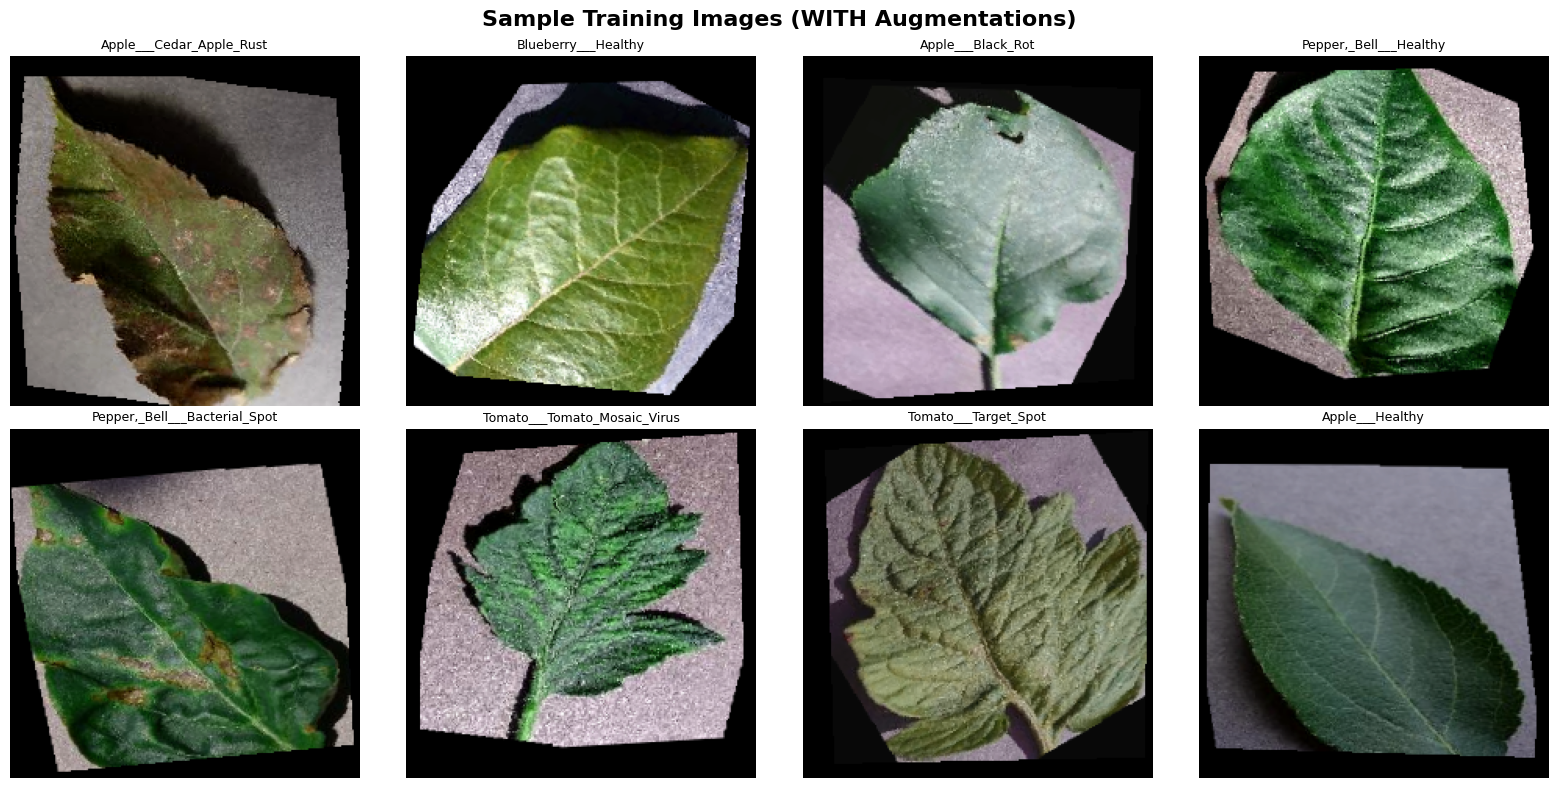

✅ Sample images displayed


In [7]:
print_section("SAMPLE VISUALIZATION")

def denormalize(tensor):
    """Denormalize tensor for visualization."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, IMAGENET_MEAN, IMAGENET_STD):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

# Get sample batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Training Images (WITH Augmentations)', 
             fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    img = denormalize(images[idx])
    img = img.permute(1, 2, 0).numpy()
    
    ax.imshow(img)
    class_name = train_dataset.classes[labels[idx]]
    ax.set_title(class_name[:30], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✅ Sample images displayed")


**# CELL 9: Model Setup**

This cell instantiates the model based on the configuration from Cell 7.

**Supported Models:**
- **MobilePlantViT**: Custom lightweight hybrid CNN-Transformer
  - Variants: `tiny`, `small`, `base`, `large`, `custom`
- **MobileNetV2**: Baseline model with ImageNet pretrained weights

**Features:**
- Automatic parameter counting and breakdown
- Forward pass timing benchmark
- Parameter budget verification (5M limit)
- Comparison mode support for training both models

**Output Variables:**
- `model`: Primary model for training
- `model_name`: Name of the primary model
- `models_dict`: Dictionary of all created models (for comparison mode)
- `model_summaries`: Performance summaries for each model
- `MODEL_INFO`: Metadata dictionary for checkpointing

In [ ]:
# ============================================================================
# CELL 9: Model Setup
# ============================================================================
"""
Instantiate the selected model based on configuration from Cell 7.
Supports MobilePlantViT variants and MobileNetV2 baseline.
"""

print_section("MODEL SETUP")

# ============================================================================
# DEVICE CONFIGURATION
# ============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================================
# MODEL INSTANTIATION FUNCTIONS
# ============================================================================
def create_mobileplant_vit(variant, num_classes, custom_config=None):
    """
    Create MobilePlantViT model based on variant selection.
    
    Args:
        variant: 'tiny', 'small', 'base', 'large', or 'custom'
        num_classes: Number of output classes
        custom_config: Dictionary of custom parameters (for 'custom' variant)
    
    Returns:
        model: Instantiated MobilePlantViT model
        model_name: String name of the model
    """
    if variant == 'tiny':
        model = mobileplant_vit_tiny(num_classes=num_classes)
        model_name = 'MobilePlantViT-Tiny'
    elif variant == 'small':
        model = mobileplant_vit_small(num_classes=num_classes)
        model_name = 'MobilePlantViT-Small'
    elif variant == 'base':
        model = mobileplant_vit_base(num_classes=num_classes)
        model_name = 'MobilePlantViT-Base'
    elif variant == 'large':
        model = mobileplant_vit_large(num_classes=num_classes)
        model_name = 'MobilePlantViT-Large'
    elif variant == 'custom':
        if custom_config is None:
            raise ValueError("custom_config required for 'custom' variant")
        
        config = MobilePlantViTConfig(
            num_classes=num_classes,
            **custom_config
        )
        model = MobilePlantViT(config)
        model_name = 'MobilePlantViT-Custom'
    else:
        raise ValueError(f"Unknown variant: {variant}")
    
    return model, model_name


def create_mobilenet_v2(num_classes, pretrained=True):
    """
    Create MobileNetV2 baseline model.
    
    Args:
        num_classes: Number of output classes
        pretrained: Whether to use ImageNet pretrained weights
    
    Returns:
        model: Instantiated MobileNetV2 model
        model_name: String name of the model
    """
    if pretrained:
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    else:
        model = models.mobilenet_v2(weights=None)
    
    # Replace classifier for our number of classes
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    
    return model, 'MobileNetV2 (Baseline)'


def get_model_summary(model, model_name, input_size=(1, 3, 224, 224), device=None):
    """
    Generate comprehensive model summary.
    
    Args:
        model: PyTorch model
        model_name: Name of the model
        input_size: Input tensor size for testing
        device: Device to run tests on (auto-detected if None)
    
    Returns:
        Dictionary with model statistics
    """
    # Auto-detect device from model parameters
    if device is None:
        try:
            device = next(model.parameters()).device
        except StopIteration:
            device = torch.device('cpu')
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # Calculate model size
    param_size_mb = total_params * 4 / (1024 * 1024)  # Assuming float32
    
    summary = {
        'model_name': model_name,
        'total_parameters': total_params,
        'trainable_parameters': trainable_params,
        'non_trainable_parameters': total_params - trainable_params,
        'model_size_mb': param_size_mb,
    }
    
    # Get parameter breakdown for MobilePlantViT
    if hasattr(model, 'get_parameter_breakdown'):
        summary['parameter_breakdown'] = model.get_parameter_breakdown()
    
    # Test forward pass timing
    model.eval()
    
    # Create test tensor on the SAME DEVICE as the model
    x = torch.randn(input_size, device=device)
    
    # Warm-up
    with torch.no_grad():
        _ = model(x)
    
    # Synchronize GPU if using CUDA (for accurate timing)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    
    # Time forward pass
    times = []
    with torch.no_grad():
        for _ in range(10):
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start = time.time()
            _ = model(x)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append(time.time() - start)
    
    summary['avg_forward_time_ms'] = np.mean(times) * 1000
    summary['std_forward_time_ms'] = np.std(times) * 1000
    
    return summary


def print_model_summary(summary, detailed=True):
    """Print formatted model summary."""
    print(f"\n📊 Model Summary: {summary['model_name']}")
    print("-" * 60)
    print(f"   Total Parameters:     {summary['total_parameters']:,}")
    print(f"   Trainable Parameters: {summary['trainable_parameters']:,}")
    print(f"   Model Size:           {summary['model_size_mb']:.2f} MB")
    print(f"   Avg Forward Time:     {summary['avg_forward_time_ms']:.2f} ± {summary['std_forward_time_ms']:.2f} ms")
    
    # Parameter budget check
    param_budget = 5_000_000
    usage_percent = (summary['total_parameters'] / param_budget) * 100
    if summary['total_parameters'] <= param_budget:
        print(f"   Parameter Budget:     ✅ {usage_percent:.1f}% of 5M limit")
    else:
        print(f"   Parameter Budget:     ❌ {usage_percent:.1f}% of 5M limit (EXCEEDED!)")
    
    # Detailed breakdown for MobilePlantViT
    if detailed and 'parameter_breakdown' in summary:
        breakdown = summary['parameter_breakdown']
        print(f"\n   📋 Parameter Breakdown:")
        print(f"      CNN Stage:         {breakdown.get('cnn_total', 'N/A'):,}")
        print(f"      Transition Stage:  {breakdown.get('transition_total', 'N/A'):,}")
        print(f"      Transformer Stage: {breakdown.get('transformer_total', 'N/A'):,}")
        print(f"      Classifier Stage:  {breakdown.get('classifier_total', 'N/A'):,}")


# ============================================================================
# CREATE MODEL(S) BASED ON CONFIGURATION
# ============================================================================

# Dictionary to store models (for comparison mode)
models_dict = {}
model_summaries = {}

# Create primary model based on MODEL_TYPE
if MODEL_TYPE == 'mobileplant_vit':
    if not MOBILEPLANT_VIT_AVAILABLE:
        raise RuntimeError(
            "MobilePlantViT selected but not available!\n"
            "Please check that the 'mobileplantvit-source-code' dataset is added to this notebook."
        )
    
    print(f"\n🔧 Creating MobilePlantViT ({MODEL_VARIANT})...")
    
    model, model_name = create_mobileplant_vit(
        variant=MODEL_VARIANT,
        num_classes=NUM_CLASSES,
        custom_config=CUSTOM_CONFIG if MODEL_VARIANT == 'custom' else None
    )
    model = model.to(device)
    
    # Get summary
    model_summaries['primary'] = get_model_summary(model, model_name)
    print_model_summary(model_summaries['primary'], detailed=True)
    
    models_dict['primary'] = {
        'model': model,
        'name': model_name,
        'type': 'mobileplant_vit',
        'variant': MODEL_VARIANT
    }

elif MODEL_TYPE == 'mobilenet_v2':
    print(f"\n🔧 Creating MobileNetV2 (Baseline)...")
    
    model, model_name = create_mobilenet_v2(
        num_classes=NUM_CLASSES,
        pretrained=True
    )
    model = model.to(device)
    
    # Get summary
    model_summaries['primary'] = get_model_summary(model, model_name)
    print_model_summary(model_summaries['primary'], detailed=False)
    
    models_dict['primary'] = {
        'model': model,
        'name': model_name,
        'type': 'mobilenet_v2',
        'variant': 'pretrained'
    }

else:
    raise ValueError(f"Unknown MODEL_TYPE: {MODEL_TYPE}")

# ============================================================================
# COMPARISON MODE: Create baseline model for comparison
# ============================================================================
if COMPARISON_MODE:
    print(f"\n" + "=" * 60)
    print("  COMPARISON MODE: Creating baseline model")
    print("=" * 60)
    
    if MODEL_TYPE == 'mobileplant_vit':
        # Create MobileNetV2 as baseline
        print(f"\n🔧 Creating MobileNetV2 baseline for comparison...")
        
        baseline_model, baseline_name = create_mobilenet_v2(
            num_classes=NUM_CLASSES,
            pretrained=True
        )
        baseline_model = baseline_model.to(device)
        
        model_summaries['baseline'] = get_model_summary(baseline_model, baseline_name)
        print_model_summary(model_summaries['baseline'], detailed=False)
        
        models_dict['baseline'] = {
            'model': baseline_model,
            'name': baseline_name,
            'type': 'mobilenet_v2',
            'variant': 'pretrained'
        }
    else:
        # Create MobilePlantViT as comparison
        print(f"\n🔧 Creating MobilePlantViT-Base for comparison...")
        
        if MOBILEPLANT_VIT_AVAILABLE:
            comparison_model, comparison_name = create_mobileplant_vit(
                variant='base',
                num_classes=NUM_CLASSES
            )
            comparison_model = comparison_model.to(device)
            
            model_summaries['comparison'] = get_model_summary(comparison_model, comparison_name)
            print_model_summary(model_summaries['comparison'], detailed=True)
            
            models_dict['comparison'] = {
                'model': comparison_model,
                'name': comparison_name,
                'type': 'mobileplant_vit',
                'variant': 'base'
            }
        else:
            print("⚠️  MobilePlantViT not available for comparison")

# ============================================================================
# COMPARISON SUMMARY
# ============================================================================
if len(model_summaries) > 1:
    print(f"\n" + "=" * 60)
    print("  MODEL COMPARISON SUMMARY")
    print("=" * 60)
    
    print(f"\n{'Metric':<25} ", end="")
    for key in model_summaries:
        print(f"{model_summaries[key]['model_name']:<25} ", end="")
    print()
    print("-" * (25 + 25 * len(model_summaries)))
    
    print(f"{'Parameters':<25} ", end="")
    for key in model_summaries:
        print(f"{model_summaries[key]['total_parameters']:,}".ljust(25), end="")
    print()
    
    print(f"{'Size (MB)':<25} ", end="")
    for key in model_summaries:
        print(f"{model_summaries[key]['model_size_mb']:.2f}".ljust(25), end="")
    print()
    
    print(f"{'Forward Time (ms)':<25} ", end="")
    for key in model_summaries:
        print(f"{model_summaries[key]['avg_forward_time_ms']:.2f}".ljust(25), end="")
    print()
    
    # Calculate efficiency
    if 'primary' in model_summaries and 'baseline' in model_summaries:
        primary_params = model_summaries['primary']['total_parameters']
        baseline_params = model_summaries['baseline']['total_parameters']
        reduction = ((baseline_params - primary_params) / baseline_params) * 100
        
        print(f"\n📈 Parameter Reduction: {reduction:.1f}% fewer parameters than baseline")

# ============================================================================
# SET PRIMARY MODEL FOR TRAINING
# ============================================================================
# The 'model' variable will be used in subsequent cells
model = models_dict['primary']['model']
model_name = models_dict['primary']['name']

print(f"\n" + "=" * 60)
print(f"  ✅ MODEL SETUP COMPLETE")
print("=" * 60)
print(f"\n   Primary Model: {model_name}")
print(f"   Parameters:    {model_summaries['primary']['total_parameters']:,}")
print(f"   Device:        {device}")
print(f"   Ready for:     Training")

# Store for later use
MODEL_INFO = {
    'name': model_name,
    'type': MODEL_TYPE,
    'variant': MODEL_VARIANT if MODEL_TYPE == 'mobileplant_vit' else 'pretrained',
    'num_classes': NUM_CLASSES,
    'parameters': model_summaries['primary']['total_parameters'],
    'device': str(device),
}

print(f"\n✅ Model info stored in MODEL_INFO dictionary")

**# CELL 10: Pipeline Verification**

In [9]:
print_section("PIPELINE VERIFICATION")

model.eval()

# Test forward pass
images_batch, labels_batch = next(iter(train_loader))
images_batch = images_batch.to(device)
labels_batch = labels_batch.to(device)

with torch.no_grad():
    start = time.time()
    outputs = model(images_batch)
    forward_time = time.time() - start
    
    _, predictions = torch.max(outputs, 1)

print(f"✅ Forward pass successful")
print(f"   Input shape:  {tuple(images_batch.shape)}")
print(f"   Output shape: {tuple(outputs.shape)}")
print(f"   Time: {forward_time*1000:.2f} ms")
print(f"   Throughput: {len(images_batch)/forward_time:.1f} images/sec")



  PIPELINE VERIFICATION
✅ Forward pass successful
   Input shape:  (64, 3, 224, 224)
   Output shape: (64, 38)
   Time: 956.51 ms
   Throughput: 66.9 images/sec


**# CELL 11: Pipeline Summary**

In [10]:
print("\n" + "=" * 80)
print("  COMPLETE PIPELINE SUMMARY")
print("=" * 80)

summary = f"""
📊 Dataset Configuration:
   • Source: PlantVillage (Kaggle)
   • Classes: {NUM_CLASSES}
   • Total Images: {split_stats['total_images']:,}
   • Train: {split_stats['train_images']:,} ({split_stats['train_images']/split_stats['total_images']*100:.1f}%)
   • Val:   {split_stats['val_images']:,} ({split_stats['val_images']/split_stats['total_images']*100:.1f}%)
   • Test:  {split_stats['test_images']:,} ({split_stats['test_images']/split_stats['total_images']*100:.1f}%)

🔄 Data Pipeline:
   • Batch Size: {BATCH_SIZE}
   • Workers: {NUM_WORKERS}
   • Train Batches: {len(train_loader):,}
   • Val Batches: {len(val_loader):,}
   • Test Batches: {len(test_loader):,}

🎨 Transformations:
   • Training: 9 steps WITH augmentations
   • Val/Test: 3 steps NO augmentations
   • Normalization: ImageNet statistics

🤖 Model:
   • Architecture: MobileNetV2
   • Parameters: {total_params:,}
   • Device: {device}
   • Output: {NUM_CLASSES} classes

✅ Pipeline Status: READY FOR TRAINING
"""

print(summary)
print("=" * 80)



  COMPLETE PIPELINE SUMMARY

📊 Dataset Configuration:
   • Source: PlantVillage (Kaggle)
   • Classes: 38
   • Total Images: 49,370
   • Train: 34,539 (70.0%)
   • Val:   7,388 (15.0%)
   • Test:  7,443 (15.1%)

🔄 Data Pipeline:
   • Batch Size: 64
   • Workers: 4
   • Train Batches: 540
   • Val Batches: 116
   • Test Batches: 117

🎨 Transformations:
   • Training: 9 steps WITH augmentations
   • Val/Test: 3 steps NO augmentations
   • Normalization: ImageNet statistics

🤖 Model:
   • Architecture: MobileNetV2
   • Parameters: 2,272,550
   • Device: cuda
   • Output: 38 classes

✅ Pipeline Status: READY FOR TRAINING



**# CELL 12: Training Loop**

In [11]:
# In CELL 14 - REPLACE the criterion line with:

print_section("TRAINING LOOP WITH CLASS BALANCING")

# Calculate class weights for loss function
use_weighted_loss = (BALANCING_STRATEGY in ['none', 'weighted_sampling'] and 
                     imbalance_ratio > 2.0)

if use_weighted_loss:
    print("🔄 Calculating class weights for weighted loss...")
    
    # Get class distribution from training set
    train_class_dist = count_images_in_dir(train_dir)[1]
    class_weights_dict = calculate_class_weights(train_class_dist)
    
    # Convert to tensor (must match class order in dataset)
    class_weights_list = [class_weights_dict[cls] for cls in train_dataset.classes]
    class_weights_tensor = torch.FloatTensor(class_weights_list).to(device)
    
    # Create weighted loss
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    print(f"✅ Weighted loss enabled")
    print(f"   Weight range: {min(class_weights_list):.3f} - {max(class_weights_list):.3f}")
else:
    # Standard loss
    criterion = nn.CrossEntropyLoss()
    print(f"✅ Standard loss (no class weights)")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                       factor=0.5, patience=3)

NUM_EPOCHS = 10  # Adjust as needed
best_val_acc = 0.0

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)
    
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
    
    # Calculate training metrics
    train_loss = train_loss / len(train_dataset)
    train_acc = train_correct / len(train_dataset)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
    
    # Calculate validation metrics
    val_loss = val_loss / len(val_dataset)
    val_acc = val_correct / len(val_dataset)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    
    # Print epoch results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_path = os.path.join(working_base, 'best_model.pth')
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Model saved (val_acc: {val_acc:.4f})")

print(f"\n🎉 Training complete! Best Val Acc: {best_val_acc:.4f}")


  TRAINING LOOP WITH CLASS BALANCING
🔄 Calculating class weights for weighted loss...
✅ Weighted loss enabled
   Weight range: 0.263 - 9.275

Epoch 1/10
------------------------------------------------------------


Training:   0%|          | 0/540 [00:00<?, ?it/s]

Validation:   0%|          | 0/116 [00:00<?, ?it/s]

Train Loss: 0.3852 | Train Acc: 0.8142
Val Loss:   0.6048 | Val Acc:   0.8473
✅ Model saved (val_acc: 0.8473)

Epoch 2/10
------------------------------------------------------------


Training:   0%|          | 0/540 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/116 [00:00<?, ?it/s]

Train Loss: 0.0746 | Train Acc: 0.9609
Val Loss:   0.1094 | Val Acc:   0.9700
✅ Model saved (val_acc: 0.9700)

Epoch 10/10
------------------------------------------------------------


Training:   0%|          | 0/540 [00:00<?, ?it/s]

Validation:   0%|          | 0/116 [00:00<?, ?it/s]

Train Loss: 0.0875 | Train Acc: 0.9560
Val Loss:   0.0907 | Val Acc:   0.9712
✅ Model saved (val_acc: 0.9712)

🎉 Training complete! Best Val Acc: 0.9712


**# CELL 13: Test Set Evaluation**

In [12]:
print_section("TEST SET EVALUATION")

# Load best model
best_model_path = os.path.join(working_base, 'best_model.pth')
model.load_state_dict(torch.load(best_model_path))
model.eval()

test_loss = 0.0
test_correct = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        test_correct += (preds == labels).sum().item()
        
        # Store for confusion matrix later
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
test_loss = test_loss / len(test_dataset)
test_acc = test_correct / len(test_dataset)

print(f"✅ Test Set Results:")
print(f"   Test Loss:     {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   Total Images:  {len(test_dataset):,}")
print(f"   Correct:       {test_correct:,}")
print(f"   Incorrect:     {len(test_dataset) - test_correct:,}")


  TEST SET EVALUATION


Testing:   0%|          | 0/117 [00:00<?, ?it/s]

✅ Test Set Results:
   Test Loss:     0.0924
   Test Accuracy: 97.11%
   Total Images:  7,443
   Correct:       7,228
   Incorrect:     215


**# CELL 14: Baseline Performance**

In [13]:
print_section("BASELINE MODEL PERFORMANCE")

baseline_results = {
    'model_name': 'MobileNetV2 (Baseline)',
    'best_val_accuracy': best_val_acc,
    'num_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'total_params': total_params,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

print(f"✅ Baseline Training Complete")
print(f"   Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"   Model Saved: best_model.pth")
print(f"   Total Parameters: {total_params:,}")

# Save results to JSON for comparison later
import json
with open('baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=4)

print("\n📝 Results saved to baseline_results.json")

results_path = os.path.join(working_base, 'baseline_results.json')
with open(results_path, 'w') as f:
    json.dump(baseline_results, f, indent=4)

print(f"\n📝 Results saved to {results_path}")


  BASELINE MODEL PERFORMANCE
✅ Baseline Training Complete
   Best Validation Accuracy: 97.12%
   Model Saved: best_model.pth
   Total Parameters: 2,272,550

📝 Results saved to baseline_results.json

📝 Results saved to /kaggle/working/MobilePlantViT/baseline_results.json


**# CELL 15: Confusion Matrix**


  CONFUSION MATRIX & CLASSIFICATION REPORT


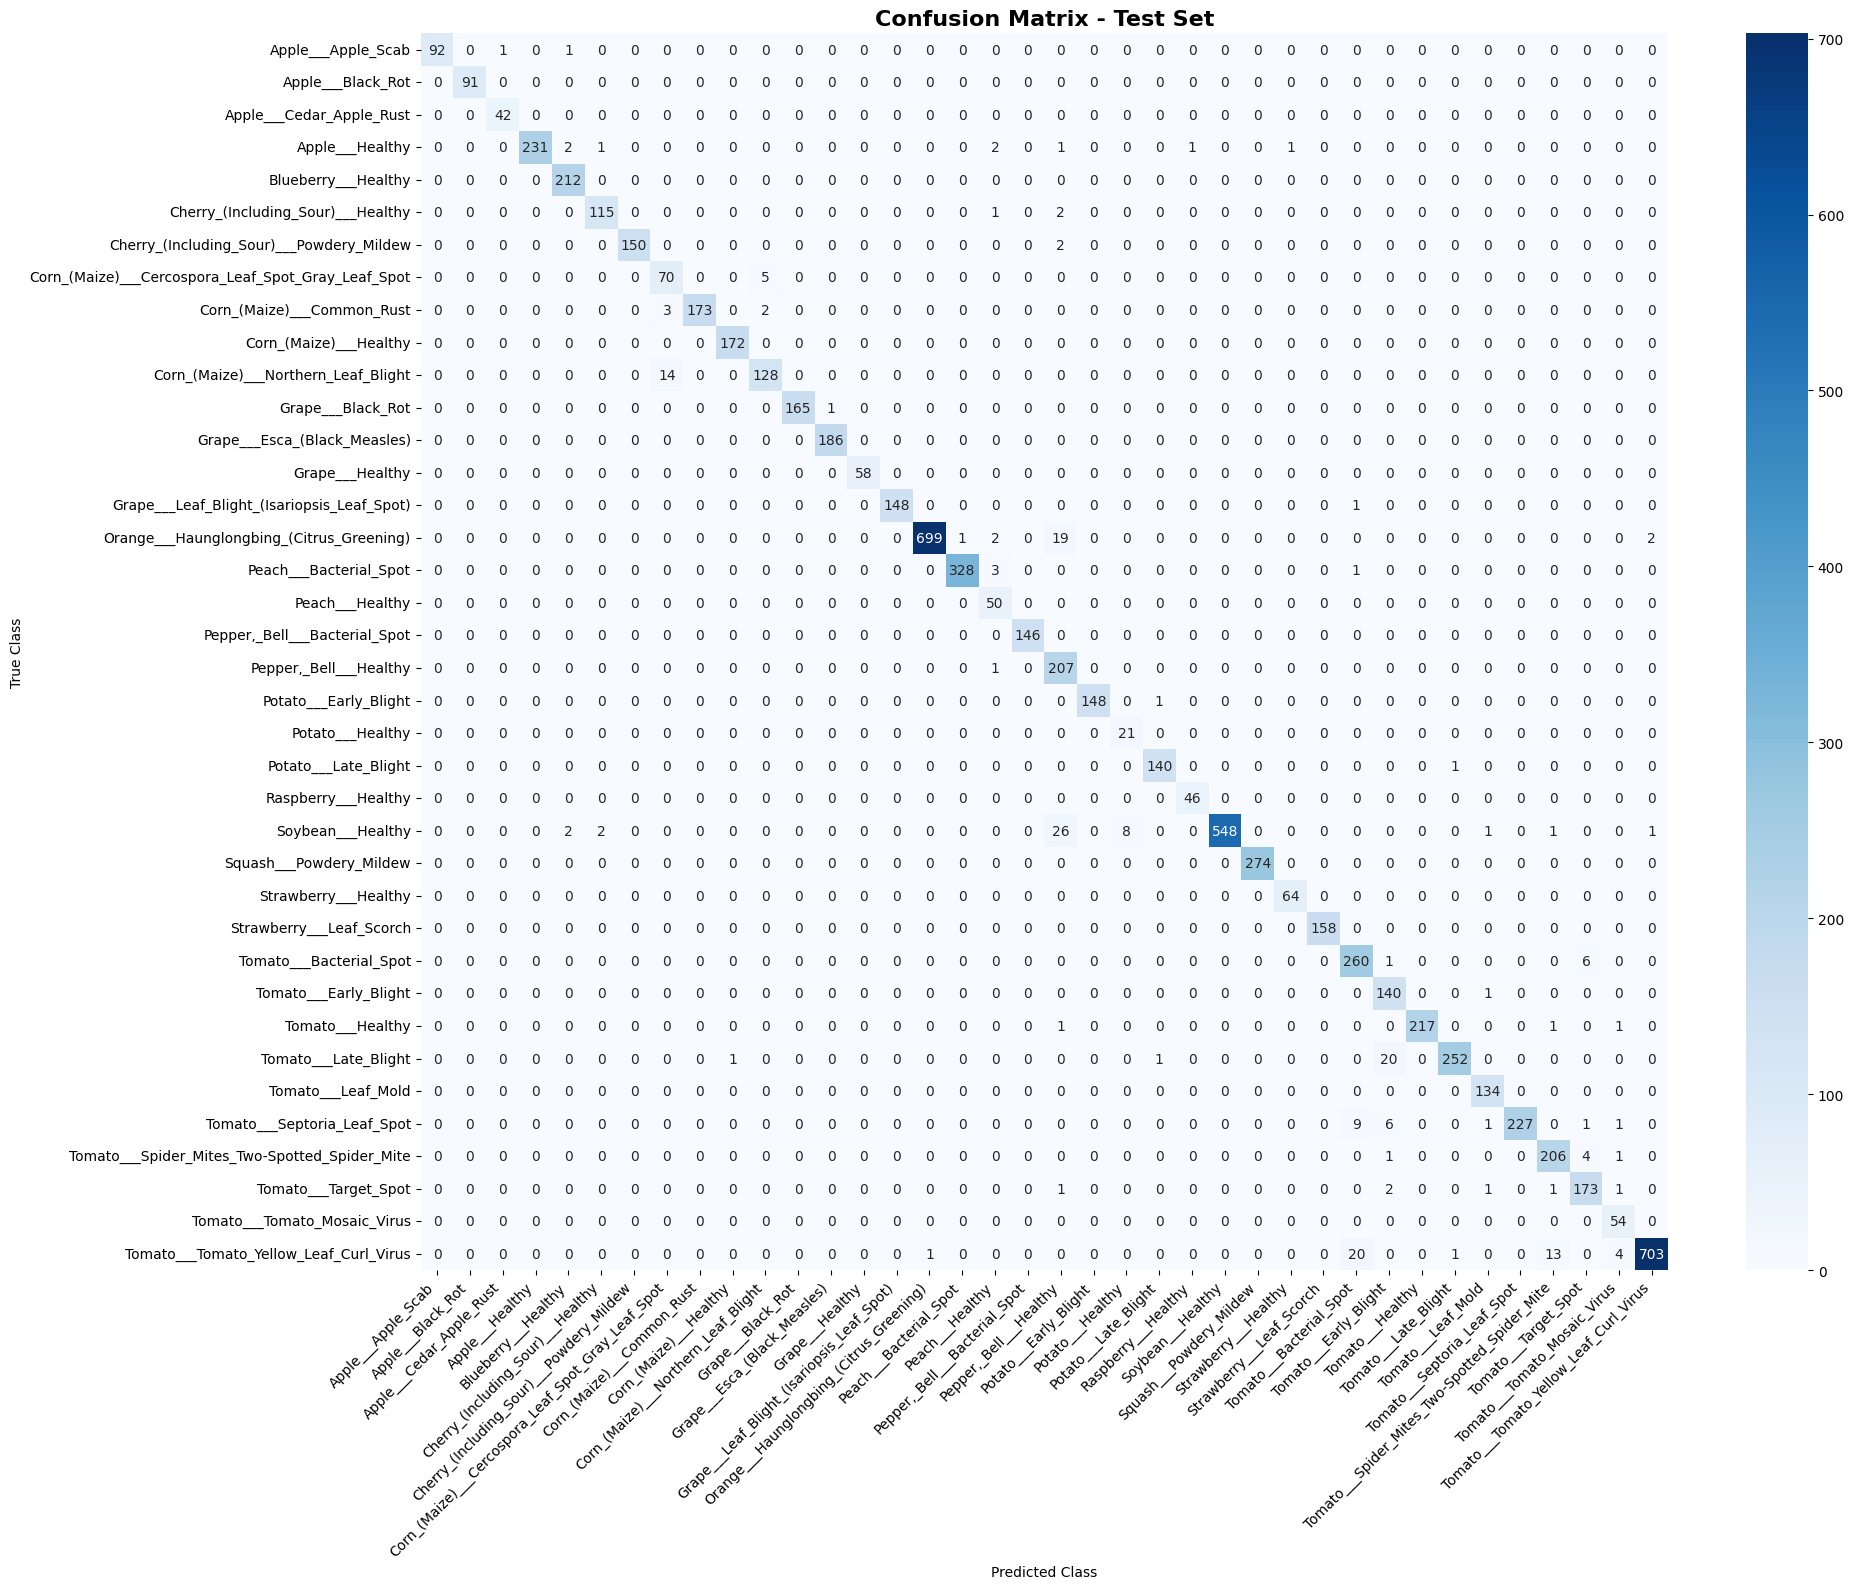


📊 Detailed Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_Scab     1.0000    0.9787    0.9892        94
                                 Apple___Black_Rot     1.0000    1.0000    1.0000        91
                          Apple___Cedar_Apple_Rust     0.9767    1.0000    0.9882        42
                                   Apple___Healthy     1.0000    0.9665    0.9830       239
                               Blueberry___Healthy     0.9770    1.0000    0.9883       212
                 Cherry_(Including_Sour)___Healthy     0.9746    0.9746    0.9746       118
          Cherry_(Including_Sour)___Powdery_Mildew     1.0000    0.9868    0.9934       152
Corn_(Maize)___Cercospora_Leaf_Spot_Gray_Leaf_Spot     0.8046    0.9333    0.8642        75
                        Corn_(Maize)___Common_Rust     1.0000    0.9719    0.9858       178
                            Corn_(Maize)___H

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print_section("CONFUSION MATRIX & CLASSIFICATION REPORT")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
print("\n📊 Detailed Classification Report:")
print(classification_report(all_labels, all_preds, 
                           target_names=train_dataset.classes,
                           digits=4))

**# CELL 16: Mislabeled Detection**


  MISLABELED IMAGE DETECTION
🔍 Analyzing training set for potentially mislabeled images...


Scanning for mislabeled:   0%|          | 0/540 [00:00<?, ?it/s]


🔍 Top 100 Potentially Mislabeled Images:
----------------------------------------------------------------------------------------------------
#    True Class                          Predicted                           Loss     Conf    
----------------------------------------------------------------------------------------------------
1    Soybean___Healthy                   Pepper,_Bell___Healthy              11.905   1.000   
2    Orange___Haunglongbing_(Citrus_Gr   Pepper,_Bell___Healthy              10.873   0.997   
3    Apple___Healthy                     Cherry_(Including_Sour)___Healthy   10.871   1.000   
4    Tomato___Tomato_Yellow_Leaf_Curl_   Tomato___Bacterial_Spot             10.862   1.000   
5    Tomato___Tomato_Yellow_Leaf_Curl_   Tomato___Bacterial_Spot             10.482   1.000   
6    Tomato___Tomato_Yellow_Leaf_Curl_   Tomato___Bacterial_Spot             10.319   1.000   
7    Orange___Haunglongbing_(Citrus_Gr   Pepper,_Bell___Healthy              10.268   0.995

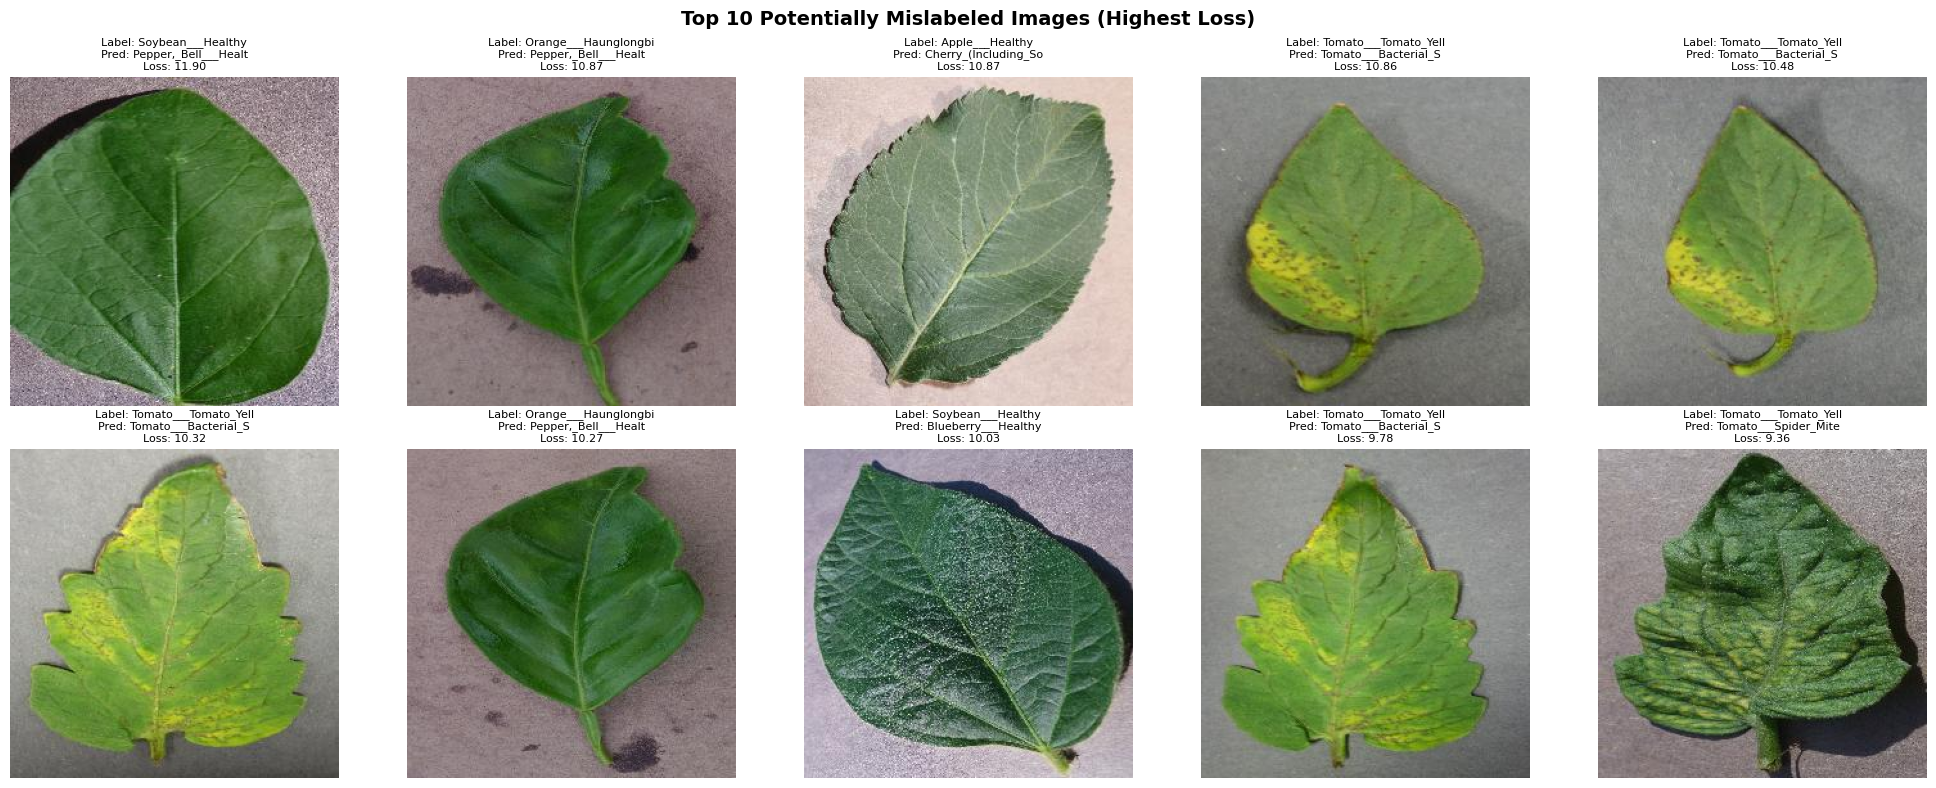


✅ Mislabeled detection complete!
⚠️  Review flagged images manually to confirm if truly mislabeled.


In [15]:
# CELL 18: Mislabeled Image Detection (Add after Cell 17)

print_section("MISLABELED IMAGE DETECTION")

from torch.nn import functional as F

def detect_mislabeled_candidates(model, dataloader, dataset, device, top_k=100):
    """
    Detect potentially mislabeled images by finding high-loss, 
    low-confidence predictions that are incorrect.
    """
    model.eval()
    suspicious_samples = []
    
    with torch.no_grad():
        sample_idx = 0
        for images, labels in tqdm(dataloader, desc="Scanning for mislabeled"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            
            # Get predictions and confidence
            max_probs, predictions = torch.max(probabilities, dim=1)
            
            # Calculate per-sample loss
            losses = F.cross_entropy(outputs, labels, reduction='none')
            
            # Find incorrect predictions
            incorrect_mask = predictions != labels
            
            for i in range(len(images)):
                if incorrect_mask[i]:
                    actual_idx = sample_idx + i
                    img_path, true_label = dataset.samples[actual_idx]
                    
                    suspicious_samples.append({
                        'index': actual_idx,
                        'path': img_path,
                        'filename': os.path.basename(img_path),
                        'true_class': dataset.classes[true_label],
                        'predicted_class': dataset.classes[predictions[i].item()],
                        'confidence': float(max_probs[i].item()),
                        'loss': float(losses[i].item()),
                        'true_label_prob': float(probabilities[i][true_label].item())
                    })
            
            sample_idx += len(images)
    
    # Sort by loss (highest first)
    suspicious_samples.sort(key=lambda x: x['loss'], reverse=True)
    
    return suspicious_samples[:top_k]


# Create non-augmented loader for training set
train_eval_dataset = datasets.ImageFolder(train_dir, transform=transform_val_test)
train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Detect suspicious samples
print("🔍 Analyzing training set for potentially mislabeled images...")
suspicious = detect_mislabeled_candidates(
    model, train_eval_loader, train_eval_dataset, device, top_k=100
)

# Display results
print(f"\n🔍 Top {len(suspicious)} Potentially Mislabeled Images:")
print("-" * 100)
print(f"{'#':<4} {'True Class':<35} {'Predicted':<35} {'Loss':<8} {'Conf':<8}")
print("-" * 100)

for idx, sample in enumerate(suspicious[:20], 1):
    print(f"{idx:<4} {sample['true_class'][:33]:<35} {sample['predicted_class'][:33]:<35} "
          f"{sample['loss']:<8.3f} {sample['confidence']:<8.3f}")

if len(suspicious) > 20:
    print(f"... and {len(suspicious) - 20} more suspicious samples")

# Save report
mislabeled_report = {
    'total_suspicious': len(suspicious),
    'detection_method': 'high_loss_incorrect_predictions',
    'threshold_info': 'Top 100 samples sorted by loss (descending)',
    'samples': suspicious
}

mislabeled_log_path = os.path.join(working_base, 'mislabeled_candidates.json')
with open(mislabeled_log_path, 'w') as f:
    json.dump(mislabeled_report, f, indent=4)

print(f"\n📝 Mislabeled candidates saved to: {mislabeled_log_path}")

# Visualize top suspicious images
if len(suspicious) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle('Top 10 Potentially Mislabeled Images (Highest Loss)', 
                 fontsize=14, fontweight='bold')
    
    for idx, ax in enumerate(axes.flat):
        if idx < len(suspicious):
            sample = suspicious[idx]
            try:
                img = Image.open(sample['path']).convert('RGB')
                ax.imshow(img)
                ax.set_title(f"Label: {sample['true_class'][:20]}\n"
                            f"Pred: {sample['predicted_class'][:20]}\n"
                            f"Loss: {sample['loss']:.2f}", fontsize=8)
            except:
                ax.text(0.5, 0.5, 'Image\nLoad\nError', ha='center', va='center')
            ax.axis('off')
        else:
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(working_base, 'mislabeled_visualization.png'), dpi=150)
    plt.show()

print("\n✅ Mislabeled detection complete!")
print("⚠️  Review flagged images manually to confirm if truly mislabeled.")